In [17]:
import re

import polars as pl
import pandas as pd
import numpy as np
import altair as alt
import pyarrow
from mpl_toolkits.axes_grid1 import make_axes_locatable
from func.UsefulFunctions import *
import geopandas as gpd
from matplotlib import pyplot as plt

This notebook takes the group data (that was extracted from the Music Brainz JSON) and inspects it. Groups are groups, choirs, orchestras unless stated otherwise.

In [18]:
groupDF = pl.read_parquet("./Data/ensemblesMusicBrainzData.parquet")


#De-duplicate the data
groupDF = groupDF.unique()


#Let's get the genres out

groupDFPandas = groupDF.to_pandas(use_pyarrow_extension_array=True)
groupDFPandas['genreList'] = groupDFPandas['genres'].map(prettifyGenres)
groupDFPandas["tagsList"] = groupDFPandas['tags'].map(prettifyGenres)
groupDF = pl.from_pandas(groupDFPandas)
display(groupDF.head(10))
tagsList = groupDF["tagsList"].explode(empty_as_null=True).drop_nulls().unique().to_list()
print(len(tagsList))
setOfFictionTags = set()

for x in tagsList:
    if re.search("ficti", x, re.IGNORECASE) is not None:
        setOfFictionTags.add(x)

print(setOfFictionTags)
setOfFictionTagsPicked = {"fictional", "fictitious artist", "fictitious-artist", "fictional artist", "fictional band"}

#find the groups who are fictititous and remove them
groupDF = groupDF.filter(
    pl.col("tagsList").list.set_intersection(setOfFictionTagsPicked).list.len() == 0
)






num_of_ids = groupDF.select(
    pl.col("id")
).unique().count().item(0,0)
print(f"There are {num_of_ids} unique IDs in the dataset (that is a snapshot from 18/07/2026)")


id,name,type,gender,country,genres,isnis,ipis,tags,life-span,genreList,tagsList
str,str,str,str,str,list[struct[4]],list[str],list[str],list[struct[2]],struct[3],list[str],list[str]
"""1565af65-d161-4d5e-a2fe-53c247…","""To Be One""","""Group""",null,"""US""",[],[],[],[],"{null,""2013"",false}",[],[]
"""a5c3927b-45fc-40fd-bee2-879149…","""Onomatorquestra""","""Group""",null,"""BR""",[],[],[],[],"{null,null,false}",[],[]
"""85010472-0b1e-4488-b372-93d331…","""Chicken Train""","""Group""",null,"""US""",[],[],[],[],"{null,null,false}",[],[]
"""8ef39705-3d95-4412-a6fb-2eab5e…","""Moving Pictures""","""Group""",null,"""AU""","[{""797e2e85-5ffd-495c-a757-8b4079052f0e"",1,"""",""pop rock""}]",[],[],"[{""pop rock"",1}]","{""1987"",""1978"",true}","[""pop rock""]","[""pop rock""]"
"""9ae00b37-874a-4a2b-9d61-781d34…","""Xciters""","""Group""",null,null,[],[],[],[],"{null,null,false}",[],[]
"""a05a4cc2-670a-4fa6-9136-a16340…","""Anchorite""","""Group""",null,"""US""",[],[],[],[],"{null,null,false}",[],[]
"""36e3a023-6fcc-4198-b107-b41bdf…","""Wadi Vision""","""Group""",null,"""GB""",[],[],[],[],"{null,null,false}",[],[]
"""e24b6b66-97a3-4bb4-bdee-31c746…","""The Junkies""","""Group""",null,null,[],[],[],[],"{null,""2006"",false}",[],[]
"""bad96c62-50f8-4159-b155-3ffb63…","""J Church""","""Group""",null,"""US""","[{""8cc9b280-230b-4a3a-b1e2-8acab0744dd3"",1,"""",""punk""}]",[],[],"[{""american"",1}, {""punk"",1}]","{""2007"",""1992"",true}","[""punk""]","[""american"", ""punk""]"


25892
{'ficticious artist', 'fictional', 'fictitious artist', 'music community the loser gushes by false edge original image wishlist supported by psyencefiction thumbnail 00:00 / 03:50 streaming + download includes high-quality download in mp3', 'fiction', 'weird fiction', 'science fiction', 'fictional artist', 'fictional band', 'fictitious-artist', 'scottish fiction'}
There are 672645 unique IDs in the dataset (that is a snapshot from 18/07/2026)


In [19]:
groupDF.head()

id,name,type,gender,country,genres,isnis,ipis,tags,life-span,genreList,tagsList
str,str,str,str,str,list[struct[4]],list[str],list[str],list[struct[2]],struct[3],list[str],list[str]
"""1565af65-d161-4d5e-a2fe-53c247…","""To Be One""","""Group""",null,"""US""",[],[],[],[],"{null,""2013"",false}",[],[]
"""a5c3927b-45fc-40fd-bee2-879149…","""Onomatorquestra""","""Group""",null,"""BR""",[],[],[],[],"{null,null,false}",[],[]
"""85010472-0b1e-4488-b372-93d331…","""Chicken Train""","""Group""",null,"""US""",[],[],[],[],"{null,null,false}",[],[]
"""8ef39705-3d95-4412-a6fb-2eab5e…","""Moving Pictures""","""Group""",null,"""AU""","[{""797e2e85-5ffd-495c-a757-8b4079052f0e"",1,"""",""pop rock""}]",[],[],"[{""pop rock"",1}]","{""1987"",""1978"",true}","[""pop rock""]","[""pop rock""]"
"""9ae00b37-874a-4a2b-9d61-781d34…","""Xciters""","""Group""",null,null,[],[],[],[],"{null,null,false}",[],[]


In [20]:
#How many people do not have a name in this dataset?
num_people_with_no_names = groupDF.select(
    pl.col("name"),
    pl.col("id")
).unique().null_count()
print(num_people_with_no_names)
print(f"There are {num_people_with_no_names.item(0,0)} entities with no name, and {num_people_with_no_names.item(0,1)} entities with no ids.")

shape: (1, 2)
┌──────┬─────┐
│ name ┆ id  │
│ ---  ┆ --- │
│ u32  ┆ u32 │
╞══════╪═════╡
│ 0    ┆ 0   │
└──────┴─────┘
There are 0 entities with no name, and 0 entities with no ids.


In [21]:
#check if there are any duplicates in ids
ids = groupDF.select(
    pl.col("id")
).is_duplicated()
print(ids.value_counts())

print("Based off of the lack of trues in the is_duplicated function. All rows are unique after the deduplication ")

shape: (1, 2)
┌───────┬────────┐
│       ┆ count  │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ false ┆ 672645 │
└───────┴────────┘
Based off of the lack of trues in the is_duplicated function. All rows are unique after the deduplication 


In [22]:
#Do a count for the countries for the dataset.
countryCount = groupDF.select(pl.col("country").value_counts(sort=True)).unnest("country")
print(countryCount)

shape: (236, 2)
┌─────────┬────────┐
│ country ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ null    ┆ 203525 │
│ US      ┆ 121112 │
│ GB      ┆ 45506  │
│ DE      ┆ 33518  │
│ JP      ┆ 29447  │
│ …       ┆ …      │
│ SS      ┆ 1      │
│ MS      ┆ 1      │
│ WF      ┆ 1      │
│ AN      ┆ 1      │
│ BQ      ┆ 1      │
└─────────┴────────┘


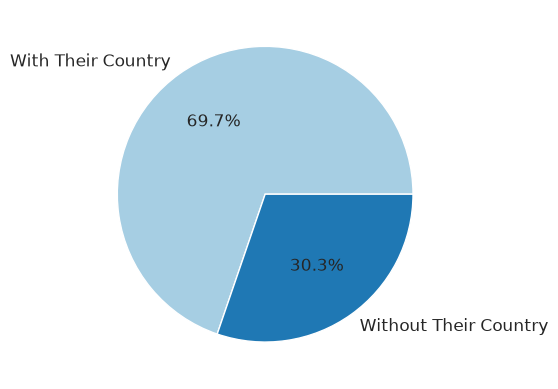

In [23]:
#Make a pie chart for people who have a country and does who don't
noCountry = (groupDF
             .filter(
                pl.col("country").is_null(),
                    )
            .select(pl.col("id")).drop_nulls().unique())
hasCountry = (groupDF
             .filter(
                pl.col("country").is_not_null(),
                    )
            .select(pl.col("id")).drop_nulls().unique())
plt.rc('font', size=12)
makePieChart(["With Their Country", "Without Their Country"], [len(hasCountry), len(noCountry)], "Country Known vs Unknown on MusicBrainz for Groups", "Paired")

,ISO_A2,geometry
0,ZW,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,ZM,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,YE,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,VN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,VE,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


country          str
count         uint32
log_count    float64
dtype: object


,ISO_A2,count,log_count
0,US,121112,11.704471
1,GB,45506,10.725599
2,DE,33518,10.419838
3,JP,29447,10.290347
4,FR,20204,9.913636
...,...,...,...
230,SS,1,0.000000
231,MS,1,0.000000
232,WF,1,0.000000
233,AN,1,0.000000


,ISO_A2,geometry,count,log_count
0,ZW,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344...",75.0,4.317488
1,ZM,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643...",54.0,3.988984
2,YE,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16...",2.0,0.693147
3,VN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ...",173.0,5.153292
4,VE,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9...",639.0,6.459904


<Axes: >

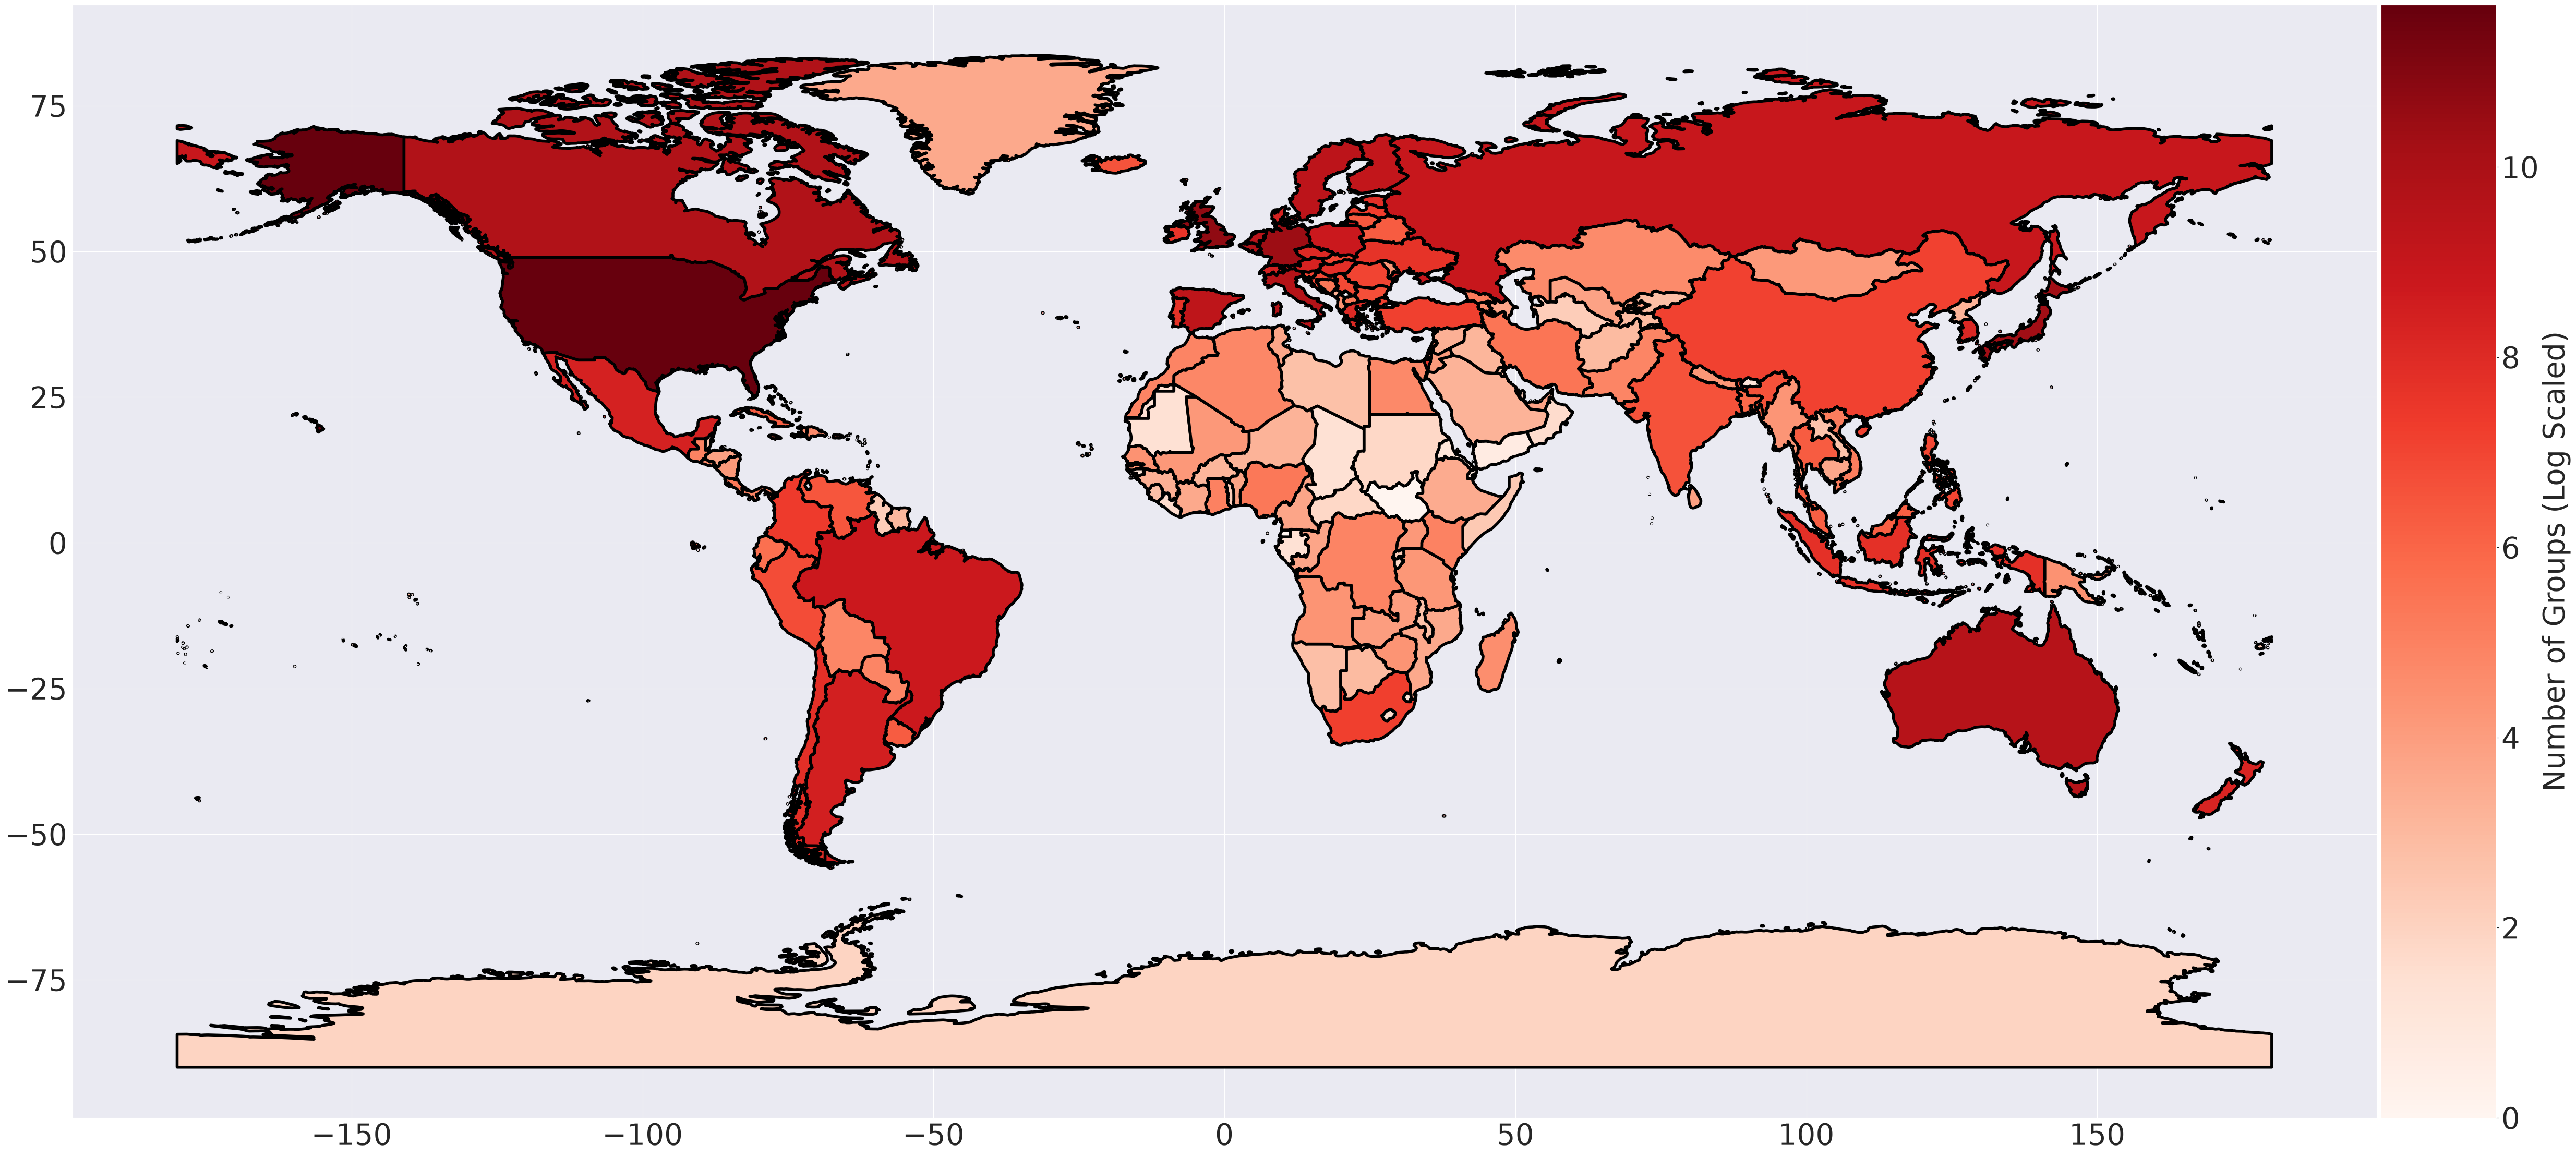

In [24]:
#Create a heatmap for the countries of artists on MusicbRAINZ

worldMap = gpd.read_file("./mapData/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")

worldMap = worldMap[['ISO_A2', 'geometry']]
display(worldMap.head())
countryCountPandas = countryCount.drop_nulls().to_pandas()
countryCountPandas["log_count"] = np.log(countryCountPandas["count"])
print(countryCountPandas.dtypes)
countryCountPandas = countryCountPandas.rename(columns={"country": "ISO_A2"})
display(countryCountPandas)
preppedCountryData = worldMap.merge(countryCountPandas, on='ISO_A2', how='left')
display(preppedCountryData.head())

plt.rc('font', size=40)
fig, axMap = plt.subplots(figsize=(60, 60))

divider = make_axes_locatable(axMap)
cax = divider.append_axes("right", size="5%", pad=0.05)
cax.tick_params(labelsize=40)
preppedCountryData.plot(column="log_count",
                        cmap="Reds",
                        edgecolor="black",
                        linewidth=4,
                        ax=axMap,
                        cax=cax,
                        legend=True,
                        legend_kwds={"label": "Number of Groups (Log Scaled)"}, )

Based off the table, the most common countries are (outside of null which shows that most groups do not have a country attached to them is) US, GB, DE, and japan

In [25]:
#What is the most common type of group for the entities
typeCount = groupDF.group_by("type").agg(pl.col("id").count())
typeCountPercent = groupDF.select(pl.col("type").value_counts(sort=True, normalize=True, name="Fraction")).unnest("type")
print(typeCount)

typeChart = (
    alt.Chart(typeCount).mark_bar().encode(
        y="id",
        x="type",
    )
    .properties(width=500, title="Frequency of Types on Music Brainz")
)
typeChart.encoding.x.title = "Type"
typeChart.encoding.y.title = "Count"
typeChart.show()

shape: (3, 2)
┌───────────┬────────┐
│ type      ┆ id     │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ Group     ┆ 650115 │
│ Orchestra ┆ 11759  │
│ Choir     ┆ 10771  │
└───────────┴────────┘


alt.Chart(...)

In [26]:
print(typeCountPercent)

shape: (3, 2)
┌───────────┬──────────┐
│ type      ┆ Fraction │
│ ---       ┆ ---      │
│ str       ┆ f64      │
╞═══════════╪══════════╡
│ Group     ┆ 0.966505 │
│ Orchestra ┆ 0.017482 │
│ Choir     ┆ 0.016013 │
└───────────┴──────────┘


The biggest type in this group is "Group" by a large percent (96.7%), and the other ensemble types exist around 1.7% and 1.6%.

In [27]:
groupDF.write_parquet("./Data/Network_groupMBData.parquet")

In [28]:
#Get the most common genre
genreCount = groupDF.select(
    pl.col("id"),
    pl.col("name"),
    pl.col("type"),
    pl.col("genreList").alias("Genre"),
)

genreCount = genreCount.explode("Genre", empty_as_null=True, keep_nulls=True)
genreCount = genreCount.unique()
number_of_genres = genreCount.select(
    pl.col("Genre").value_counts(sort=True)
).unnest("Genre")
print(number_of_genres)




shape: (1_339, 2)
┌────────────────────┬────────┐
│ Genre              ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ null               ┆ 571695 │
│ rock               ┆ 11423  │
│ punk               ┆ 9983   │
│ black metal        ┆ 6911   │
│ metal              ┆ 6831   │
│ …                  ┆ …      │
│ forró de favela    ┆ 1      │
│ kuda lumping       ┆ 1      │
│ carnatic classical ┆ 1      │
│ hapa haole         ┆ 1      │
│ lambada            ┆ 1      │
└────────────────────┴────────┘


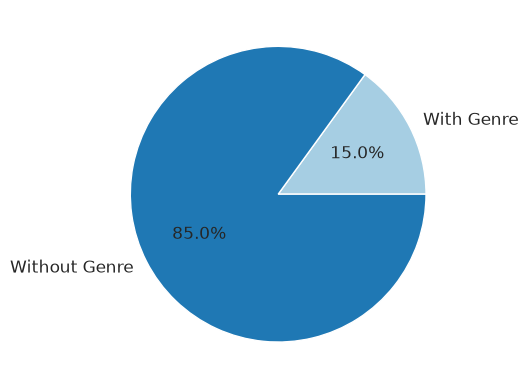

In [29]:
#Make a pie chart for people who have at least one genre and those who dont
noGenre = (genreCount
           .filter(
    pl.col("Genre").is_null(),
    ).select(pl.col("id")).drop_nulls().unique())
hasGenre = (genreCount
              .filter(
    pl.col("Genre").is_not_null(),
).select(pl.col("id")).drop_nulls().unique())
plt.rc('font', size=12)
makePieChart(["With Genre", "Without Genre"], [len(hasGenre), len(noGenre)],
             "Country Known vs Unknown on MusicBrainz for Groups", "Paired")

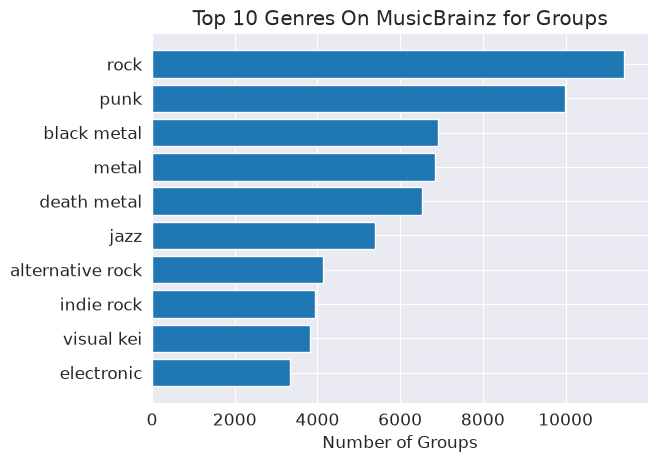

In [30]:
#Top genres
top10Genres = number_of_genres.drop_nulls()[0:10]
plt.rc('font', size=12)
horizontalBarChart(top10Genres["Genre"], top10Genres["count"], "Top 10 Genres On MusicBrainz for Groups", "Number of Groups")

In [31]:
#Look for the type and genre split using group by.
genreCount.group_by(["type",'Genre']).agg(pl.col('id').count())

type,Genre,id
str,str,u32
"""Group""","""bubblegum dance""",69
"""Group""","""jug band""",10
"""Group""","""plainchant""",1
"""Group""","""sea shanty""",20
"""Orchestra""","""swing""",17
…,…,…
"""Orchestra""","""conducted improvisation""",1
"""Group""","""livetronica""",9
"""Group""","""chap hop""",1


In [32]:
#Get the group and country count
groupDF.group_by(["type","country"]).agg(pl.col('id').count())

type,country,id
str,str,u32
"""Group""","""TM""",9
"""Choir""","""US""",1318
"""Orchestra""","""IN""",11
"""Choir""","""AM""",8
"""Choir""","""GE""",18
…,…,…
"""Group""","""TR""",1186
"""Group""","""NP""",68
"""Group""","""BD""",355
